<div align="center">

# 🩺 Patient Survey Model 🩺

</div>

## 📚 Import Basics Libraries

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler , OneHotEncoder

from imblearn.pipeline import Pipeline # sklearn dont have ordinal encoder
from imblearn.over_sampling import SMOTE # solve imbalance
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


## 👁️ Reading Dataset

In [126]:
data = pd.read_excel("patient_severity_dataset.xlsx")
df = data.copy()
df.head()

,patient_id,age,gender,bmi,blood_pressure_systolic,blood_pressure_diastolic,glucose_level,cholesterol,heart_rate,wbc_count,hemoglobin,smoking_status,diabetes,severity
0,P0490,42.0,Male,29.0 kg/m2,119/77,NaN,199.0 mg/dL,250.0,55.0,6.71,11.6,NaN,No,Moderate
1,P0430,26.0,Male,26.6 kg/m2,126/69,NaN,NaN,NaN,58.0,7.50,15.7,Yes,No,Mild
2,P0083,NaN,Male,20.3 kg/m2,121/84,NaN,147.0 mg/dL,297.0,99.0,11.40,12.6,No,No,Moderate
3,P0121,59.0,Female,27.0 kg/m2,106/105,NaN,189.0 mg/dL,174.0,106.0,NaN,11.7,Yes,No,Mild
4,P0222,38.0,Female,22.2 kg/m2,127/62,NaN,107.0 mg/dL,155.0,107.0,6.46,14.9,No,No,Healthy


## 🧹 Data Preprocessing 

###  1. Removing kg/m2

In [127]:
df["bmi"] = df["bmi"].astype(str).str.replace(r"[^\d.]", "", regex=True)

###  2. Split blood_pressure_systolic Values

In [129]:
mask = (
    df["blood_pressure_diastolic"].isna() |
    df["blood_pressure_diastolic"].astype(str).str.strip().eq("")
)

temp = (
    df.loc[mask, "blood_pressure_systolic"]
    .astype(str)
    .str.extract(r'(\d+)\D+(\d+)')
)

df.loc[mask, "blood_pressure_systolic"] = temp[0]
df.loc[mask, "blood_pressure_diastolic"] = temp[1]

###  3. Removing mg/dL

In [130]:
df["glucose_level"] = df["glucose_level"].astype(str).str.replace(r"[^\d.]", "", regex=True)

### 4. Change Column Data Type

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                515 non-null    object 
 1   age                       483 non-null    float64
 2   gender                    515 non-null    object 
 3   bmi                       515 non-null    object 
 4   blood_pressure_systolic   515 non-null    object 
 5   blood_pressure_diastolic  515 non-null    object 
 6   glucose_level             515 non-null    object 
 7   cholesterol               483 non-null    float64
 8   heart_rate                484 non-null    float64
 9   wbc_count                 482 non-null    float64
 10  hemoglobin                484 non-null    float64
 11  smoking_status            500 non-null    object 
 12  diabetes                  504 non-null    object 
 13  severity                  515 non-null    object 
dtypes: float64

#### Columns: [ bmi , blood_pressure_diastolic , blood_pressure_systolic , glucose_level ] 

In [132]:
cols = [
    "bmi",
    "blood_pressure_diastolic",
    "blood_pressure_systolic",
    "glucose_level"
]

for col in cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    ).astype(float)

### 5. Replace Nulls

##### * Replacing Null Values [ 'age' , 'bmi' , 'glucose_level' , 'cholesterol' , 'heart_rate' , 'wbc_count' , 'hemoglobin' , 'smoking_status' , 'diabetes' ] .

##### * We Will Replacing Null Values in Piepline Step To Avoid Data Leakage Problem .

### 6. Duplicated Rows

In [133]:
print(f'Number Of Duplicated Rows : {df.duplicated().sum()}')

Number Of Duplicated Rows : 15


In [134]:
df = df.drop_duplicates()

### 7. Checking For Negative Values

In [135]:
num_cols = df.select_dtypes(include="number").columns

(df[num_cols] < 0).sum()

age                         0
bmi                         0
blood_pressure_systolic     0
blood_pressure_diastolic    0
glucose_level               0
cholesterol                 0
heart_rate                  0
wbc_count                   0
hemoglobin                  0
dtype: int64

### 8. Checking For Outliers

In [136]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    outliers = ((df[col] < Q1 - 1.5*IQR) | 
                (df[col] > Q3 + 1.5*IQR)).sum()
    
    print(col, outliers)

age 0
bmi 0
blood_pressure_systolic 0
blood_pressure_diastolic 0
glucose_level 0
cholesterol 0
heart_rate 0
wbc_count 8
hemoglobin 5


In [137]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    if col == "severity_encoded":
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    outliers_df = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    ]

    if len(outliers_df) > 0:
        print(f"\n--- {col} ---")
        print(outliers_df[[col]])


--- wbc_count ---
     wbc_count
20       13.35
104       1.67
121       1.86
208      13.74
285      14.02
312      13.00
440       2.10
493       1.64

--- hemoglobin ---
     hemoglobin
140        18.6
142         7.6
254         7.1
388         8.1
493         7.0


## 🔍 Exploration Data Analysis

### 1. Understanding The Data

In [138]:
df.head()

,patient_id,age,gender,bmi,blood_pressure_systolic,blood_pressure_diastolic,glucose_level,cholesterol,heart_rate,wbc_count,hemoglobin,smoking_status,diabetes,severity
0,P0490,42.0,Male,29.02,119.0,77.0,199.0,250.0,55.0,6.71,11.6,NaN,No,Moderate
1,P0430,26.0,Male,26.62,126.0,69.0,NaN,NaN,58.0,7.50,15.7,Yes,No,Mild
2,P0083,NaN,Male,20.32,121.0,84.0,147.0,297.0,99.0,11.40,12.6,No,No,Moderate
3,P0121,59.0,Female,27.02,106.0,105.0,189.0,174.0,106.0,NaN,11.7,Yes,No,Mild
4,P0222,38.0,Female,22.22,127.0,62.0,107.0,155.0,107.0,6.46,14.9,No,No,Healthy


In [139]:
print(f'Shape Of Data : {df.shape}')
print(f'Number Of Rows : {df.shape[0]}')
print(f'Number Of Columns : {df.shape[1]}')

Shape Of Data : (500, 14)
Number Of Rows : 500
Number Of Columns : 14


In [140]:
df.describe()

,age,bmi,blood_pressure_systolic,blood_pressure_diastolic,glucose_level,cholesterol,heart_rate,wbc_count,hemoglobin
count,470.000000,470.000000,500.000000,500.000000,470.000000,470.000000,470.000000,470.000000,470.000000
mean,51.008511,26.363191,134.030000,83.368000,163.208511,237.900000,87.031915,7.697638,13.401915
std,19.859956,5.259947,25.990231,14.326307,52.003476,50.162472,18.276631,2.138885,1.938582
min,18.000000,12.100000,90.000000,60.000000,71.000000,150.000000,55.000000,1.640000,7.000000
25%,34.000000,22.700000,112.000000,71.000000,118.000000,195.250000,71.000000,6.392500,12.100000
50%,51.000000,26.350000,133.500000,82.000000,167.000000,240.000000,87.000000,7.715000,13.400000
75%,69.000000,30.000000,156.250000,95.000000,209.750000,280.000000,103.000000,8.967500,14.700000
max,84.000000,40.900000,179.000000,109.000000,249.000000,319.000000,119.000000,14.020000,18.600000


## 2. Target Distribution

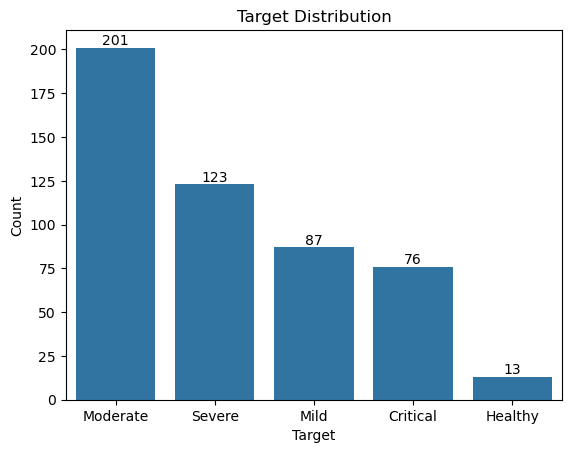

In [141]:
order = df["severity"].value_counts().index

ax = sns.countplot(
    x=df["severity"],
    order=order
)

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## 3. Features Disctibution

### 3.1. Numeric Features

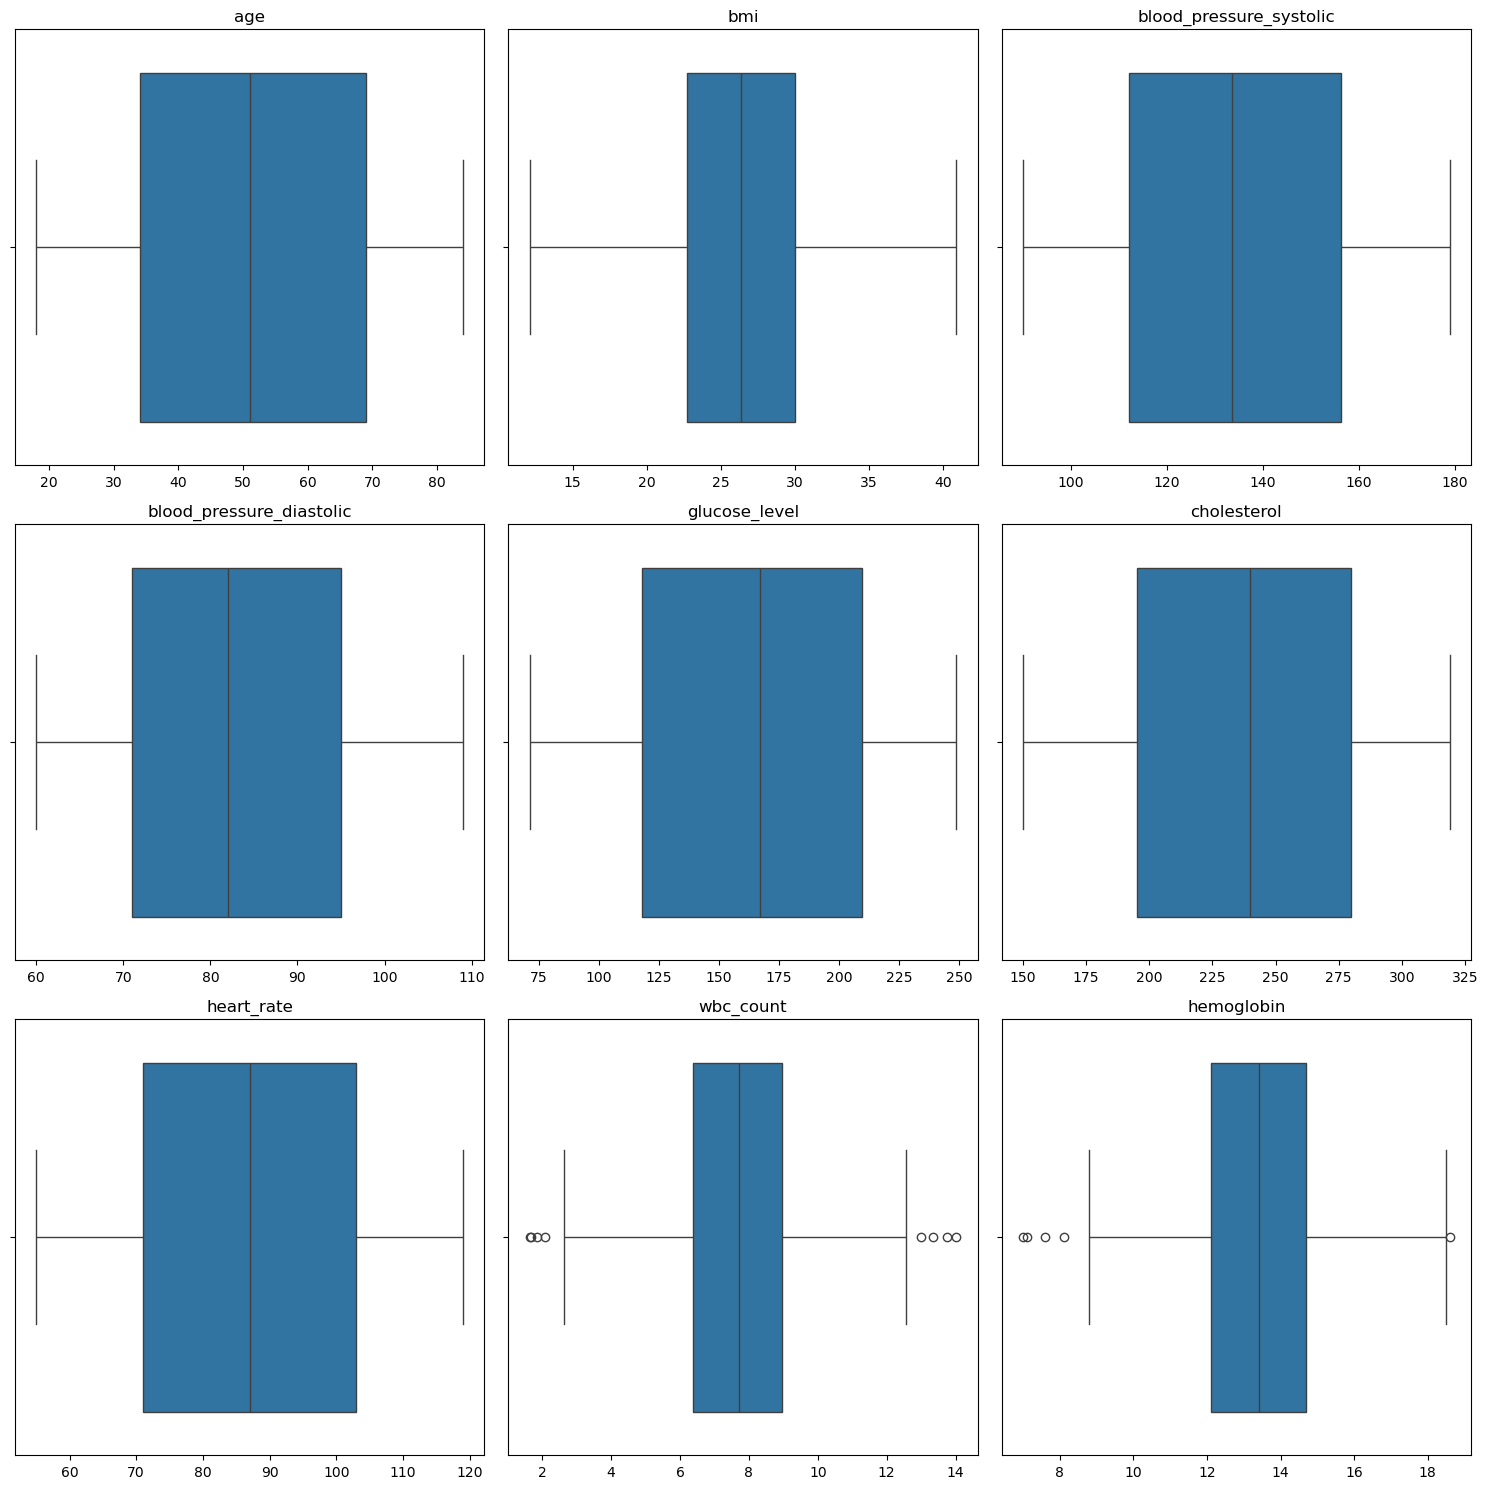

In [142]:
num_cols = df.select_dtypes(include="number").columns

n_cols = 3  
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))

axes = axes.flatten() 

for i, col in enumerate(num_cols):

    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 3.2. Categorical Features

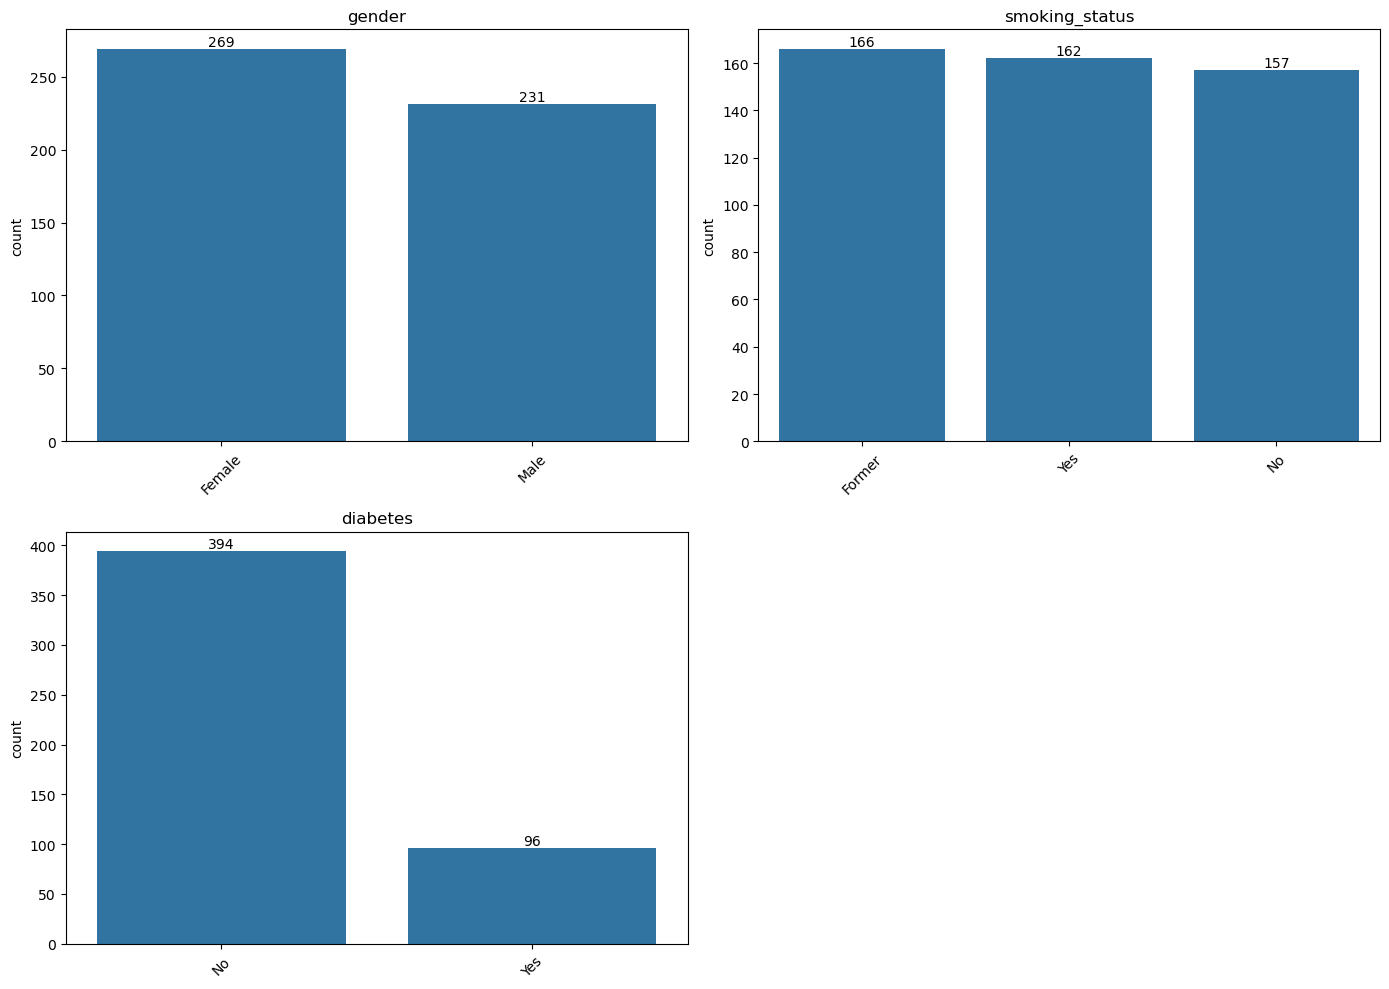

In [143]:
cat_cols = df.select_dtypes(include="object").columns

cat_cols = [col for col in cat_cols if col not in ["patient_id", "severity"]]

n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    ax = sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)

    for container in ax.containers:
        ax.bar_label(container)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 4. Features vs Target

### 4.1. Numeric Feautures

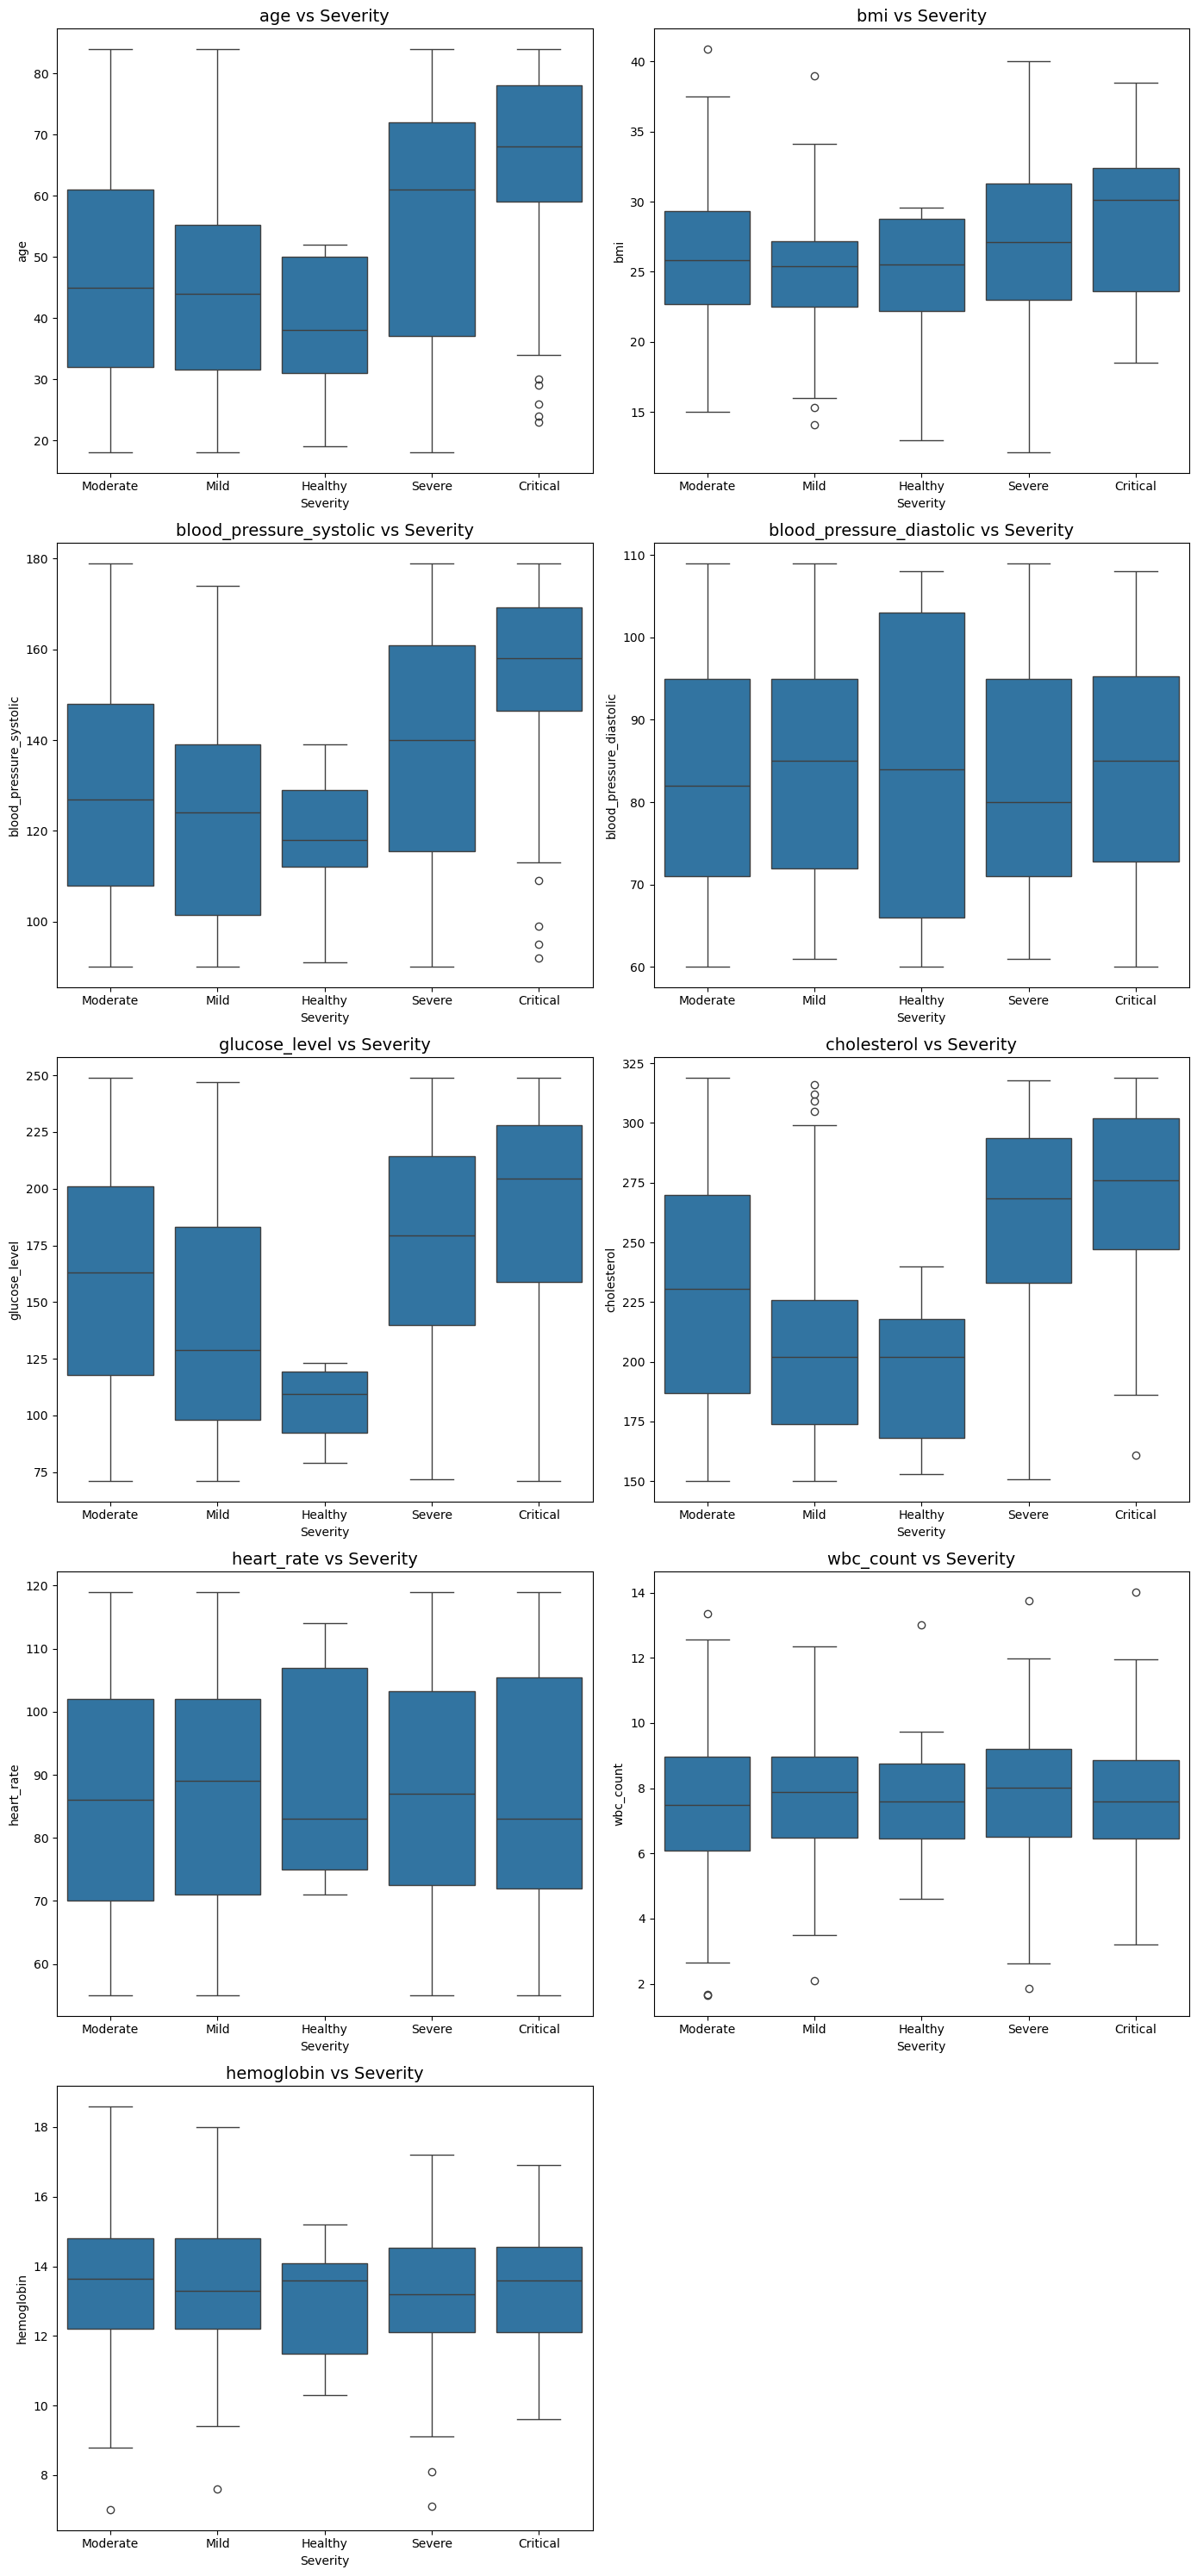

In [144]:
numeric_cols = df.select_dtypes(include="number").columns

n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6*n_rows))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    sns.boxplot(
        data=df,
        x="severity",
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Severity", fontsize=14)
    axes[i].set_xlabel("Severity")
    axes[i].set_ylabel(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 4.2. Categorical Feautures

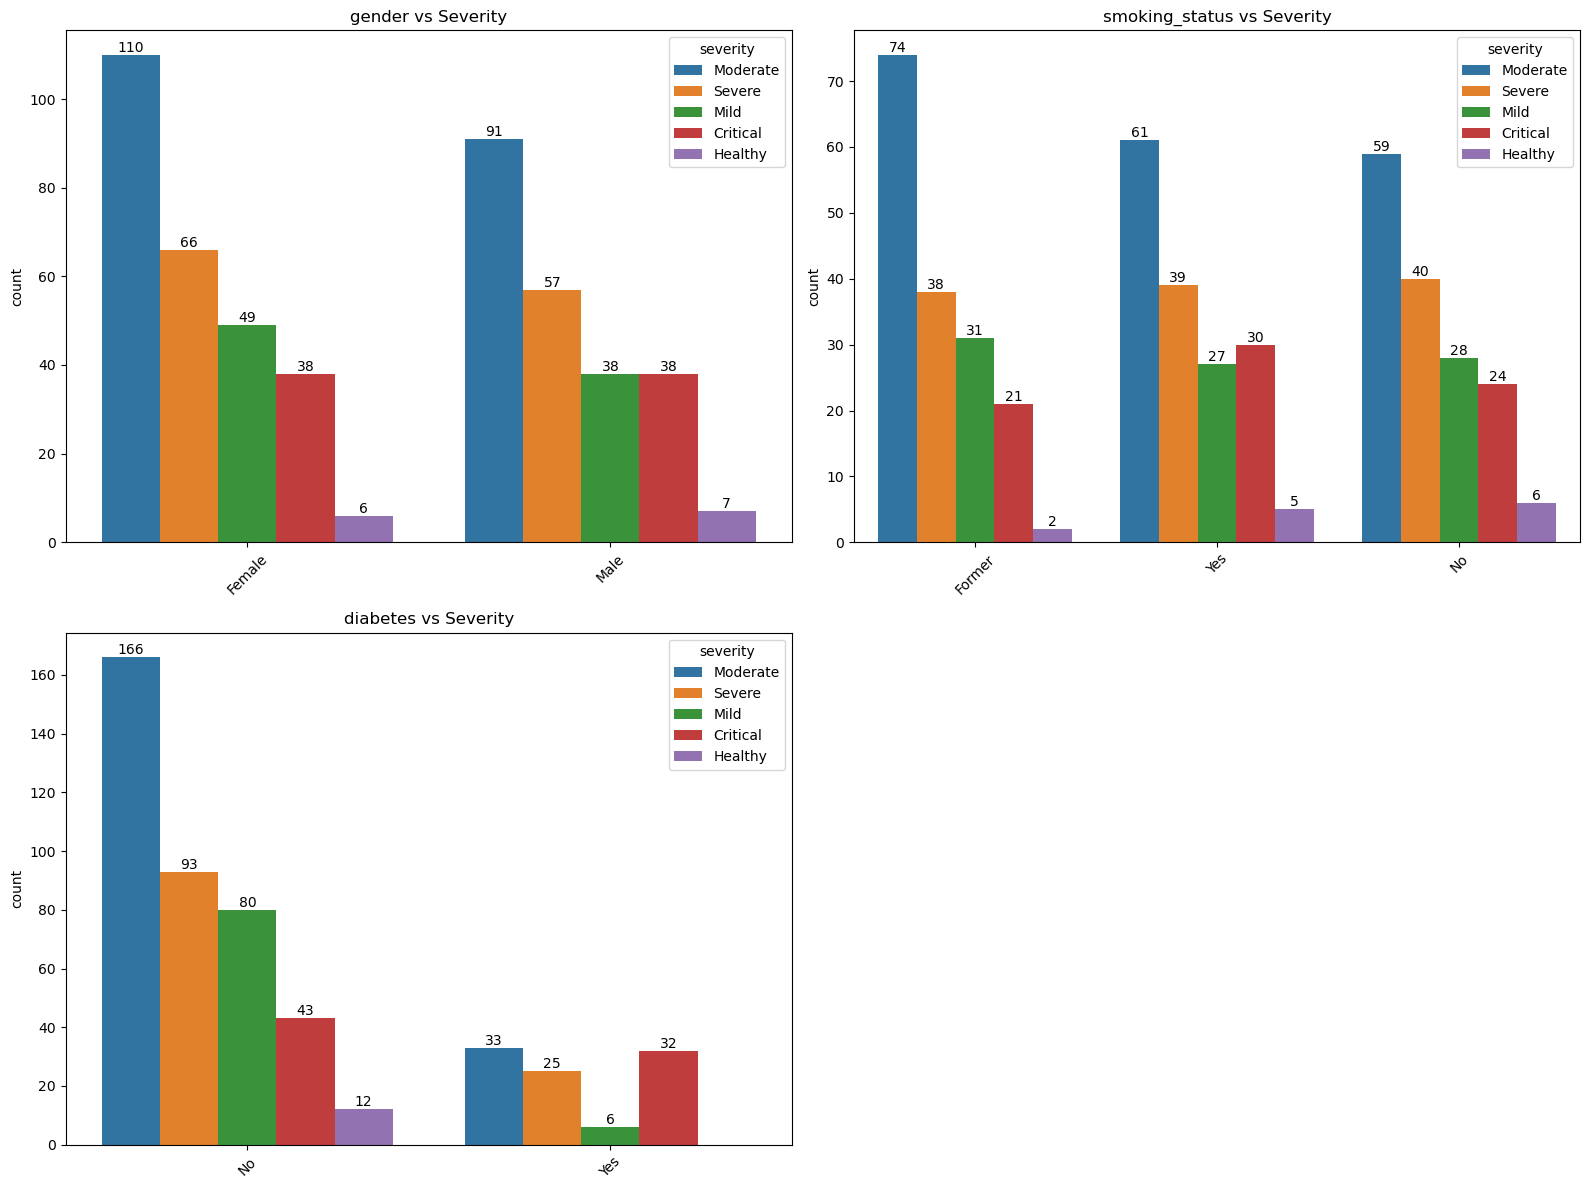

In [145]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols = [col for col in cat_cols if col not in ["severity", "patient_id"]]

n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6*n_rows))

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    temp = (
        df.groupby([col, "severity"])
        .size()
        .reset_index(name="count")
    )

    temp = temp.sort_values("count", ascending=False)

    ax = sns.barplot(
        data=temp,
        x=col,
        y="count",
        hue="severity",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Severity")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)

    for container in ax.containers:
        ax.bar_label(container, fmt="%d")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 5. Features & Target Correlation

### 5.1. Encode The Target (Ordianl Encoding)

In [146]:
mapping = {
    "Healthy": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3,
    "Critical": 4
}

df["severity_encoded"] = df["severity"].map(mapping)

### 5.2. Encode The Feautres (Binary Encoding)

In [147]:
binary_map = {
    "Male": 1,
    "Female": 0,
    "Yes": 1,
    "No": 0
}

binary_cols = ["gender", "smoking_status", "diabetes"]

for col in binary_cols:
    df[col] = df[col].map(binary_map)

### 5.3. The Correlation

In [148]:
corr_df = df.corr(numeric_only=True)[["severity_encoded"]].sort_values(
    by="severity_encoded",
    ascending=False
)

display(corr_df)

,severity_encoded
severity_encoded,1.000000
cholesterol,0.421537
blood_pressure_systolic,0.368046
age,0.350723
glucose_level,0.342478
diabetes,0.264637
bmi,0.232027
smoking_status,0.036429
wbc_count,0.025768
gender,0.024368


### 5.4. Inverse Mapping

In [149]:
gender_map_inv = {1: "Male", 0: "Female"}
yesno_map_inv = {1: "Yes", 0: "No"}

df["gender"] = df["gender"].map(gender_map_inv)
df["smoking_status"] = df["smoking_status"].map(yesno_map_inv)
df["diabetes"] = df["diabetes"].map(yesno_map_inv)

In [150]:
df.head()

,patient_id,age,gender,bmi,blood_pressure_systolic,blood_pressure_diastolic,glucose_level,cholesterol,heart_rate,wbc_count,hemoglobin,smoking_status,diabetes,severity,severity_encoded
0,P0490,42.0,Male,29.02,119.0,77.0,199.0,250.0,55.0,6.71,11.6,NaN,No,Moderate,2
1,P0430,26.0,Male,26.62,126.0,69.0,NaN,NaN,58.0,7.50,15.7,Yes,No,Mild,1
2,P0083,NaN,Male,20.32,121.0,84.0,147.0,297.0,99.0,11.40,12.6,No,No,Moderate,2
3,P0121,59.0,Female,27.02,106.0,105.0,189.0,174.0,106.0,NaN,11.7,Yes,No,Mild,1
4,P0222,38.0,Female,22.22,127.0,62.0,107.0,155.0,107.0,6.46,14.9,No,No,Healthy,0


## ✂️ Split Features & Target

In [151]:
X = df.drop(columns= ['patient_id' , 'severity_encoded' , 'severity' , 'heart_rate' , 'hemoglobin' , 'blood_pressure_diastolic'])
y = df['severity']

## ✂️ Split Train & Test

In [152]:
X_train , X_test , y_train , y_test = train_test_split( X , y , test_size = 0.2 , random_state = 42 , stratify = y)

#### We Will use 3 Models [ Decision Tree , Logistic Regression , SVC ]

## 1.1 🌿 Decision Tree Pipeline

In [171]:
num_cols = ['age' , 'bmi' , 'blood_pressure_systolic' , 'glucose_level' , 'cholesterol' , 'wbc_count']
cat_cols = ['gender' , 'smoking_status' , 'diabetes' ]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])


cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])


preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)


decision_tree_pipeline = Pipeline([
    ("Preprocessor", preprocessor),
    ("SMOTE", SMOTE(random_state=42)),
    ("Model", DecisionTreeClassifier(random_state=42))
])

decision_tree_pipeline.fit(X_train, y_train)



,steps,"[('Preprocessor', ...), ('SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 1.2 🔮 Decision Tree Prediction

In [187]:
y_pred = decision_tree_pipeline.predict(X_test) 

## 1.3 📋 Decision Tree Evaluation

In [188]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.64


## 2.1 🧠 Logistic Regression Pipeline

In [181]:
num_cols = ['age' , 'bmi' , 'blood_pressure_systolic' , 'glucose_level' , 'cholesterol' , 'wbc_count']
cat_cols = ['gender' , 'smoking_status' , 'diabetes' ]


num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])


cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])


preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)


logistic_pipeline = Pipeline([
    ("Preprocessor", preprocessor),
    ("SMOTE", SMOTE(random_state=42)),
    ("Model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])


logistic_pipeline.fit(X_train, y_train)

,steps,"[('Preprocessor', ...), ('SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 2.2 🔮 Logistic Regression Prediction

In [185]:
y_predict = logistic_pipeline.predict(X_test)

## 2.3 📋 Logistic Regression Evaluation

In [186]:
print("accuracy" , accuracy_score(y_test , y_predict))

accuracy 0.42


## 3.1 🛠 SVM Pipeline

In [182]:
num_cols = ['age' , 'bmi' , 'blood_pressure_systolic' , 'glucose_level' , 'cholesterol' , 'wbc_count']
cat_cols = ['gender' , 'smoking_status' , 'diabetes' ]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])


cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])


preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)


svm_pipeline = Pipeline([
    ("Preprocessor", preprocessor),
    ("SMOTE", SMOTE(random_state=42)),
    ("Model", SVC(
        kernel="rbf",
        random_state=42
    ))
])


svm_pipeline.fit(X_train, y_train)


,steps,"[('Preprocessor', ...), ('SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 3.2 🔮 SVC Prediction

In [183]:
y_predict = svm_pipeline.predict(X_test)

## 3.3 📋 SVC Evaluation

In [184]:
print("Accuracy:", accuracy_score(y_test, y_predict))

Accuracy: 0.53


### 🥇 Decision Tree Accuracy : 64% 
### 🥈 SVC Accuracy : 53% 
### 🥉 Logistic Regression Accuracy : 42% 

## 🔧 Hyperparameter Tuning (Decision Tree)

In [194]:
param_grid = {
    "Model__max_depth": [3, 5, 7, 10, None],
    "Model__min_samples_split": [2, 5, 10],
    "Model__min_samples_leaf": [1, 2, 4],
}


grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'Model__max_depth': [3, 5, ...], 'Model__min_samples_leaf': [1, 2, ...], 'Model__min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


## 📋 Hyperparameter Evaluation (Decision Tree)

In [195]:
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'Model__max_depth': None, 'Model__min_samples_leaf': 1, 'Model__min_samples_split': 2}


## ⚙️ Prediction Funtion

In [196]:
def predict_severity(
    age,
    bmi,
    blood_pressure_systolic,
    glucose_level,
    cholesterol,
    wbc_count,
    gender,
    smoking_status,
    diabetes
):

    input_data = pd.DataFrame({
        "age": [age],
        "bmi": [bmi],
        "blood_pressure_systolic": [blood_pressure_systolic],
        "glucose_level": [glucose_level],
        "cholesterol": [cholesterol],
        "wbc_count": [wbc_count],
        "gender": [gender],
        "smoking_status": [smoking_status],
        "diabetes": [diabetes]
    })


    prediction = decision_tree_pipeline.predict(input_data)

    return prediction[0]

## 💾 Save Model

In [198]:
with open("Patient_Servey.pkl", "wb") as f:
    pickle.dump(decision_tree_pipeline, f)